In [5]:
from pathlib import Path
import copy
import json
import math
import sys

import numpy as np
import yaml

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax.numpy as jnp

from astropy.io import fits as astropy_fits
from astropy import constants as const
from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

REPO = Path("/mnt/ceph/users/spandey/map_godmax/GODMAX")
SRC_DIR = REPO / "src"
OUTPUT_DIR = REPO / "notebooks" / "test" / "plots" / "multiprobe_theory_predictions_all_probes"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl

print("repo:", REPO)
print("src:", SRC_DIR)
print("outputs:", OUTPUT_DIR)

repo: /mnt/ceph/users/spandey/map_godmax/GODMAX
src: /mnt/ceph/users/spandey/map_godmax/GODMAX/src
outputs: /mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes


## Parameters


In [ ]:
DEFAULT_CONFIG_PATH = REPO / "param_files" / "params_default.yaml"
PGE_CONFIG_PATH = REPO / "param_files" / "Pge" / "params_v2.yaml"

PARAMETER_OVERRIDES = {}


def read_yaml(path):
    with open(path, "r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def deep_update(base, override):
    out = copy.deepcopy(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = deep_update(out[key], value)
        else:
            out[key] = copy.deepcopy(value)
    return out


def coerce_numeric_strings(obj):
    if isinstance(obj, dict):
        return {key: coerce_numeric_strings(value) for key, value in obj.items()}
    if isinstance(obj, list):
        return [coerce_numeric_strings(value) for value in obj]
    if isinstance(obj, str):
        try:
            return float(obj)
        except ValueError:
            return obj
    return obj


params_default = coerce_numeric_strings(read_yaml(DEFAULT_CONFIG_PATH))
params_pge = coerce_numeric_strings(read_yaml(PGE_CONFIG_PATH))

# Match test_bary.ipynb: a simple one-level merge for the four GODMAX dictionaries.
params = {
    "sim_params": {**params_default["sim_params"], **params_pge.get("sim_params", {})},
    "halo_params": {**params_default["halo_params"], **params_pge.get("halo_params", {})},
    "analysis": {**params_default["analysis"], **params_pge.get("analysis", {})},
    "other_params": {**params_default["other_params"], **params_pge.get("other_params", {})},
}
params = deep_update(params, PARAMETER_OVERRIDES)

# Match test_bary's ell and survey-k grids.
lmin, lmax, dl_log_array = 10.0, 8000.0, 0.005325851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_eff = (l_array_all[1:] + l_array_all[:-1]) / 2.0
params["halo_params"]["ell_array"] = jnp.asarray(l_array_eff)
params["analysis"]["l_array_survey"] = jnp.asarray(l_array_eff)
params["analysis"]["dl_array_survey"] = jnp.asarray(dl_array)

ks = np.geomspace(3.0e-3, 10.0, 10)
params["analysis"]["k_array_survey"] = jnp.asarray(ks / (params["sim_params"]["cosmo"]["H0"] / 100.0))

print("default config:", DEFAULT_CONFIG_PATH)
print("Pge override:", PGE_CONFIG_PATH)
print("ell grid from test_bary:", float(l_array_eff[0]), float(l_array_eff[-1]), len(l_array_eff))
print("survey k grid:", np.asarray(params["analysis"]["k_array_survey"]))

default config: /mnt/ceph/users/spandey/map_godmax/GODMAX/param_files/params_default.yaml
Pge override: /mnt/ceph/users/spandey/map_godmax/GODMAX/param_files/Pge/params_v2.yaml
ell grid from test_bary: 10.026700292778399 7973.419435267746 1255
survey k grid: [4.46428571e-03 1.09946891e-02 2.70778342e-02 6.66875706e-02
 1.64238840e-01 4.04489116e-01 9.96179985e-01 2.45340239e+00
 6.04226482e+00 1.48809524e+01]


In [7]:
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz


def _fits_bin_columns(hdu):
    return [name for name in hdu.columns.names if name.startswith("BIN")]


def _normalized_nz_from_fits(hdu, col, z_array):
    nz = np.asarray(hdu.data[col], dtype=float)
    nz = np.nan_to_num(nz, nan=0.0, posinf=0.0, neginf=0.0)
    nz = np.clip(nz, 0.0, None)
    norm = np.trapezoid(nz, z_array)
    if norm <= 0.0:
        raise ValueError(f"{col} in {hdu.name} has non-positive integral")
    return nz / norm


def to_comoving_nz(z_array, nz_array, cosmo, surface_density_arcmin2=1.0):
    z_array = np.asarray(z_array, dtype=float)
    nz_array = np.asarray(nz_array, dtype=float)
    scale_fac_a_array = jnp.asarray(1.0 / (1.0 + z_array))
    chi_array = np.asarray(radial_comoving_distance(cosmo, scale_fac_a_array))
    dchi_dz_array = np.asarray((const.c.value * 1e-3) / bkgrd.H(cosmo, scale_fac_a_array))
    dV_dzdOmega_array = chi_array**2 * dchi_dz_array
    arcmin2_to_sr = (180.0 * 60.0 / np.pi) ** 2
    dndz_per_sr = surface_density_arcmin2 * arcmin2_to_sr * nz_array
    return np.divide(
        dndz_per_sr,
        dV_dzdOmega_array,
        out=np.zeros_like(nz_array),
        where=dV_dzdOmega_array > 0.0,
    )


def build_cosmology(cosmo_params):
    return Cosmology(
        Omega_c=cosmo_params["Om0"] - cosmo_params["Ob0"],
        Omega_b=cosmo_params["Ob0"],
        h=cosmo_params["H0"] / 100.0,
        sigma8=cosmo_params["sigma8"],
        n_s=cosmo_params["ns"],
        Omega_k=0.0,
        w0=cosmo_params["w0"],
        wa=0.0,
    )


def install_lsst_y1_nz(params_in):
    p = copy.deepcopy(params_in)
    analysis = p["analysis"]
    other = p["other_params"]
    halo = p["halo_params"]

    lsst_fits_path = REPO / "data" / "forecast" / "lsst_simulate_Y1.fits"
    if not lsst_fits_path.exists():
        raise FileNotFoundError(lsst_fits_path)

    lsst_y1_lens_nbar_arcmin2_total = 18.0
    hod_nbar_comoving_floor = 1.0e-5
    hod_nbar_comoving_ceiling = 5.0e-3
    requested_nbins_lens = None
    requested_nbins_source = None

    with astropy_fits.open(lsst_fits_path) as df:
        lens_hdu = df["nz_lens"]
        source_hdu = df["nz_source"]
        lens_cols = _fits_bin_columns(lens_hdu)
        source_cols = _fits_bin_columns(source_hdu)

        if requested_nbins_lens is not None:
            lens_cols = lens_cols[:requested_nbins_lens]
        if requested_nbins_source is not None:
            source_cols = source_cols[:requested_nbins_source]

        nbins_lens = len(lens_cols)
        nbins_source = len(source_cols)
        z_lens = np.asarray(lens_hdu.data["Z_MID"], dtype=float)
        z_source = np.asarray(source_hdu.data["Z_MID"], dtype=float)
        nz_lens = {i: _normalized_nz_from_fits(lens_hdu, col, z_lens) for i, col in enumerate(lens_cols)}
        nz_source = {i: _normalized_nz_from_fits(source_hdu, col, z_source) for i, col in enumerate(source_cols)}

    analysis["nz_lens_info_dict"] = {"z_array_lens": z_lens, "nbins_lens": nbins_lens}
    for i in range(nbins_lens):
        analysis["nz_lens_info_dict"][f"nz{i}"] = nz_lens[i]

    analysis["nz_source_info_dict"] = {"z_array_source": z_source, "nbins": nbins_source}
    for i in range(nbins_source):
        analysis["nz_source_info_dict"][f"nz{i}"] = nz_source[i]

    other["Delta_z_bias_array"] = np.zeros(nbins_source)
    other["mult_shear_bias_array"] = np.zeros(nbins_source)

    cosmo_jax = build_cosmology(p["sim_params"]["cosmo"])
    z_gal = z_lens
    lens_bin_nbar_arcmin2 = np.full(nbins_lens, lsst_y1_lens_nbar_arcmin2_total / nbins_lens)
    lens_bin_weights = lens_bin_nbar_arcmin2 / np.sum(lens_bin_nbar_arcmin2)
    nz_gal = np.sum(np.vstack([nz_lens[i] for i in range(nbins_lens)]) * lens_bin_weights[:, None], axis=0)
    nz_gal /= np.trapezoid(nz_gal, z_gal)
    nz_gal_comoving_raw = to_comoving_nz(
        z_gal,
        nz_gal,
        cosmo_jax,
        surface_density_arcmin2=lsst_y1_lens_nbar_arcmin2_total,
    )
    nz_gal_comoving = np.clip(nz_gal_comoving_raw, hod_nbar_comoving_floor, hod_nbar_comoving_ceiling)
    analysis["nbar_gal_comoving_zarray"] = z_gal
    analysis["nbar_gal_comoving_val"] = nz_gal_comoving
    analysis["nbar_lens_bins"] = np.asarray(lens_bin_nbar_arcmin2, dtype=float)

    zmax_lsst = float(max(z_lens[-1], z_source[-1]))
    analysis["zmax_for_Cls"] = zmax_lsst
    halo["zmax"] = max(float(halo.get("zmax", zmax_lsst)), zmax_lsst)

    p["lsst_y1_nz_metadata"] = {
        "fits_path": lsst_fits_path,
        "nbins_lens": nbins_lens,
        "nbins_source": nbins_source,
        "z_lens": z_lens,
        "z_source": z_source,
        "nz_lens": nz_lens,
        "nz_source": nz_source,
        "nbar_lens_bins": lens_bin_nbar_arcmin2,
        "nbar_gal_comoving": nz_gal_comoving,
    }
    return p


def prepare_params_for_mode(params_in, *, is_cmb_lensing):
    p = copy.deepcopy(params_in)
    analysis = p["analysis"]
    other = p["other_params"]
    analysis["model_galaxies"] = True
    analysis["model_tSZ"] = True
    analysis["is_cmb_lensing"] = bool(is_cmb_lensing)

    if is_cmb_lensing:
        z_source = np.asarray(params_in["analysis"]["nz_source_info_dict"]["z_array_source"], dtype=float)
        dummy_nz = np.ones_like(z_source, dtype=float)
        dummy_nz /= np.trapezoid(dummy_nz, z_source)
        analysis["nz_source_info_dict"] = {"z_array_source": z_source, "nbins": 1, "nz0": dummy_nz}
        other["Delta_z_bias_array"] = np.zeros(1)
        other["mult_shear_bias_array"] = np.zeros(1)
    return p


params_lsst = install_lsst_y1_nz(params)
wl_params = prepare_params_for_mode(params_lsst, is_cmb_lensing=False)
cmb_params = prepare_params_for_mode(params_lsst, is_cmb_lensing=True)

meta = params_lsst["lsst_y1_nz_metadata"]
print(f"Loaded LSST Y1 n(z): {meta['fits_path']}")
print(f"Lens bins: {meta['nbins_lens']}; source bins: {meta['nbins_source']}")
print("Lens-bin densities [arcmin^-2]:", meta["nbar_lens_bins"])
print("HOD comoving nbar range:", float(np.min(meta["nbar_gal_comoving"])), float(np.max(meta["nbar_gal_comoving"])))
print("WL source bins:", wl_params["analysis"]["nz_source_info_dict"]["nbins"])
print("lens bins:", wl_params["analysis"]["nz_lens_info_dict"]["nbins_lens"])
print("CMB source bins:", cmb_params["analysis"]["nz_source_info_dict"]["nbins"])

Loaded LSST Y1 n(z): /mnt/ceph/users/spandey/map_godmax/GODMAX/data/forecast/lsst_simulate_Y1.fits
Lens bins: 1; source bins: 5
Lens-bin densities [arcmin^-2]: [18.]
HOD comoving nbar range: 1e-05 0.005
WL source bins: 5
lens bins: 1
CMB source bins: 1


## Build source-theory objects

The standard weak-lensing object computes `gg`, `gy`, `ykappa_shear`, `gkappa_shear`, and `gtau`. A second object is built with `is_cmb_lensing=True` to compute `gkappa_CMBlensing`. Both objects use the same halo, gas, galaxy, and lens-kernel parameters.

In [8]:
def build_src_cls(param_block):
    sim = param_block["sim_params"]
    halo = param_block["halo_params"]
    analysis = param_block["analysis"]
    other = param_block["other_params"]
    base = base_class(sim, halo, analysis, other)
    profiles = Profiles(sim, halo, analysis, other, base_class_obj=base)
    pkz = get_Pkz(sim, halo, analysis, other, Profiles_obj=profiles)
    cls = get_Cl(sim, halo, analysis, other, Pkz_obj=pkz)
    return cls


cls_wl = build_src_cls(wl_params)
cls_cmb = build_src_cls(cmb_params)

ell = np.asarray(cls_wl.ell_array, dtype=np.float64)
ell_cmb = np.asarray(cls_cmb.ell_array, dtype=np.float64)
if ell.shape != ell_cmb.shape or not np.allclose(ell, ell_cmb):
    raise ValueError("WL and CMB-lensing Cl objects used different ell grids.")

print(f"ell grid: {ell[0]:.4g} .. {ell[-1]:.4g}, n={ell.size}")
print("WL Cl_gal_gal shape:", np.shape(cls_wl.Cl_gal_gal_tot_mat))
print("WL Cl_gal_kappa shape:", np.shape(cls_wl.Cl_gal_kappa_tot_mat))
print("CMB Cl_gal_kappa shape:", np.shape(cls_cmb.Cl_gal_kappa_tot_mat))

ell grid: 10.03 .. 7973, n=1255
WL Cl_gal_gal shape: (1255, 1, 1)
WL Cl_gal_kappa shape: (1255, 1, 5)
CMB Cl_gal_kappa shape: (1255, 1, 1)


## Inline multi-probe extraction

`get_Cl` stores the needed source arrays, but does not package them under the requested probe names. The extraction below is intentionally notebook-local. For `gtau`, the notebook uses the physically normalized optical-depth line-of-sight integral with `ne0 * (1 + z)^3` included inside the kernel. The raw `src` `Cl_gal_tau_tot_mat` is also kept in memory as `raw_gtau_from_src` for debugging, but the `gtau` group below uses the corrected optical-depth normalization.

In [9]:
def trapz(y, x, axis=-1):
    return np.trapezoid(y, x=x, axis=axis) if hasattr(np, "trapezoid") else np.trapz(y, x=x, axis=axis)


def ne0_cm3(cosmo_params, helium_mass_fraction=0.24):
    # Critical density in g / cm^3: rho_crit,0 = 1.878e-29 h^2.
    h = float(cosmo_params["H0"]) / 100.0
    rho_crit_0 = 1.878e-29 * h**2
    proton_mass_g = 1.67262192369e-24
    return rho_crit_0 * float(cosmo_params["Ob0"]) * (1.0 - helium_mass_fraction / 2.0) / proton_mass_g


def corrected_gal_tau_cls_zdependent(cls_obj):
    z = np.asarray(cls_obj.z_array_for_Cls, dtype=np.float64)
    chi = np.asarray(cls_obj.chi_array_for_Cls, dtype=np.float64)
    dchi_dz = np.asarray(cls_obj.dchi_dz_array_for_Cls, dtype=np.float64)
    wg = np.asarray(cls_obj.Wg_mat, dtype=np.float64)
    wtau = np.asarray(cls_obj.Wtau_array, dtype=np.float64)
    pge = np.asarray(cls_obj.cached_power_spectra[2, 4], dtype=np.float64)

    wtau_corrected = wtau * ne0_cm3(cls_obj.cosmo_params) * (1.0 + z) ** 3
    prefac_tau = wtau_corrected / chi**2
    out = np.zeros((len(cls_obj.ell_array), wg.shape[0]), dtype=np.float64)
    for j in range(wg.shape[0]):
        prefac_g = wg[j] / (dchi_dz * chi**2)
        integrand = pge * prefac_g[None, :] * prefac_tau[None, :] * chi[None, :] ** 2 * dchi_dz[None, :]
        out[:, j] = trapz(integrand, z, axis=1)
    return out


def extract_requested_probe_cls(cls_wl, cls_cmb):
    nb_lens = int(cls_wl.nbins_lens)
    nb_source = int(cls_wl.nbins)
    groups = {"gg": {}, "gy": {}, "ykappa_shear": {}, "gkappa_shear": {}, "gtau": {}, "gkappa_CMBlensing": {}}

    cl_gg = np.asarray(cls_wl.Cl_gal_gal_tot_mat, dtype=np.float64)
    for i in range(nb_lens):
        for j in range(i, nb_lens):
            groups["gg"][f"g{i + 1}_g{j + 1}"] = cl_gg[:, i, j]

    cl_gy = np.asarray(cls_wl.Cl_gal_y_tot_mat, dtype=np.float64)
    for i in range(nb_lens):
        groups["gy"][f"g{i + 1}_y"] = cl_gy[:, i]

    cl_yk = np.asarray(cls_wl.Cl_kappa_y_tot_mat, dtype=np.float64)
    for s in range(nb_source):
        groups["ykappa_shear"][f"y_kappa_shear{s + 1}"] = cl_yk[:, s]

    cl_gk = np.asarray(cls_wl.Cl_gal_kappa_tot_mat, dtype=np.float64)
    for i in range(nb_lens):
        for s in range(nb_source):
            groups["gkappa_shear"][f"g{i + 1}_kappa_shear{s + 1}"] = cl_gk[:, i, s]

    cl_gtau = corrected_gal_tau_cls_zdependent(cls_wl)
    for i in range(nb_lens):
        groups["gtau"][f"g{i + 1}_tau"] = cl_gtau[:, i]

    cl_gkcmb = np.asarray(cls_cmb.Cl_gal_kappa_tot_mat, dtype=np.float64)
    for i in range(int(cls_cmb.nbins_lens)):
        groups["gkappa_CMBlensing"][f"g{i + 1}_kappa_CMB"] = cl_gkcmb[:, i, 0]

    return groups


cls_groups = extract_requested_probe_cls(cls_wl, cls_cmb)
raw_gtau_from_src = np.asarray(cls_wl.Cl_gal_tau_tot_mat, dtype=np.float64)

for group, spectra in cls_groups.items():
    print(f"{group:18s}: {len(spectra):2d} spectra")
    for name, values in spectra.items():
        if not np.all(np.isfinite(values)):
            raise ValueError(f"Non-finite values in {group}/{name}")

gg                :  1 spectra
gy                :  1 spectra
ykappa_shear      :  5 spectra
gkappa_shear      :  5 spectra
gtau              :  1 spectra
gkappa_CMBlensing :  1 spectra


In [10]:
npz_payload = {"ell": ell}
for group, spectra in cls_groups.items():
    for name, values in spectra.items():
        npz_payload[f"{group}__{name}"] = np.asarray(values, dtype=np.float64)

npz_path = OUTPUT_DIR / "src_only_multiprobe_cls.npz"
np.savez_compressed(npz_path, **npz_payload)
print("saved:", npz_path)

saved: /mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_multiprobe_cls.npz


## Plot the requested Cls

`gg` is plotted as `C_ell`. The other probe groups are plotted as `D_ell = ell(ell+1) C_ell / (2 pi)` for easier visual comparison across multipoles.

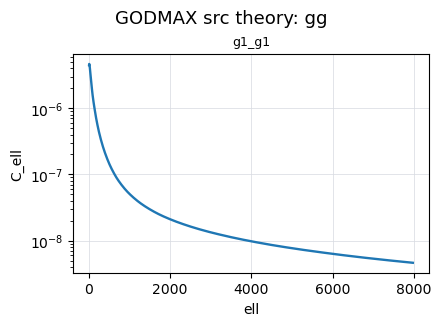

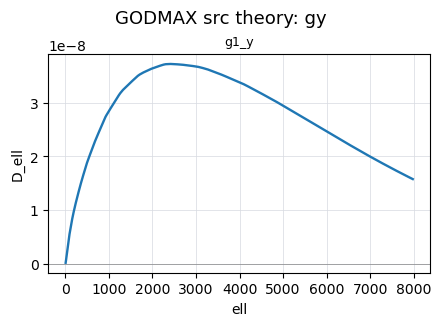

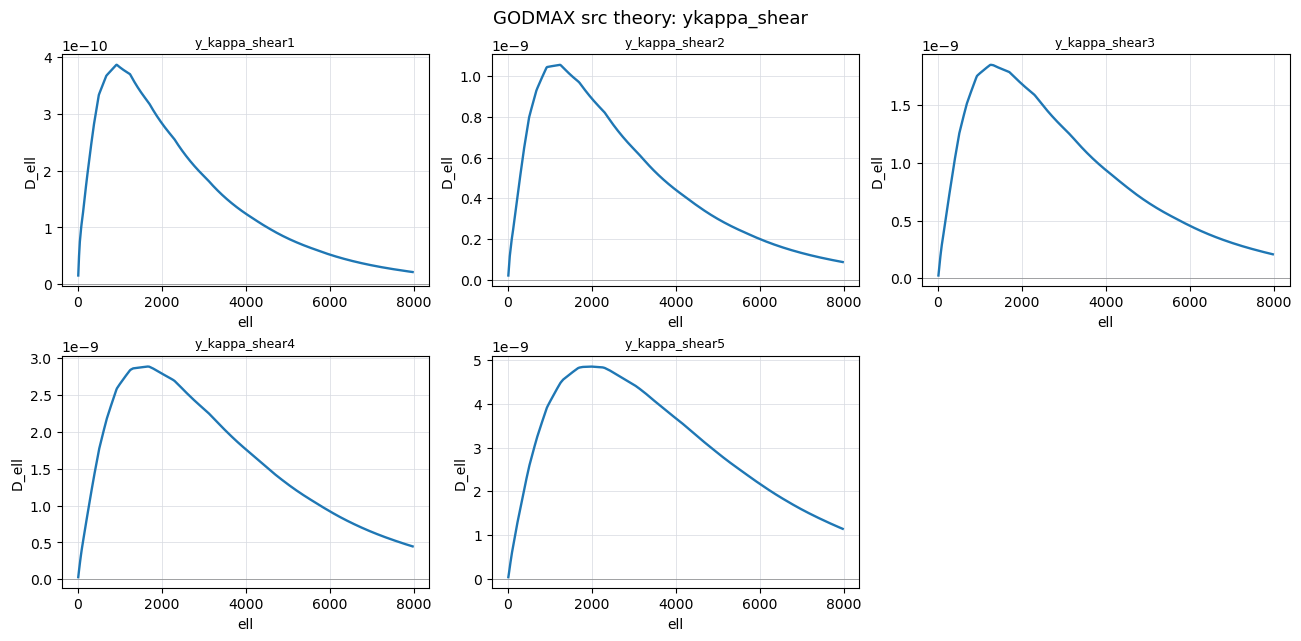

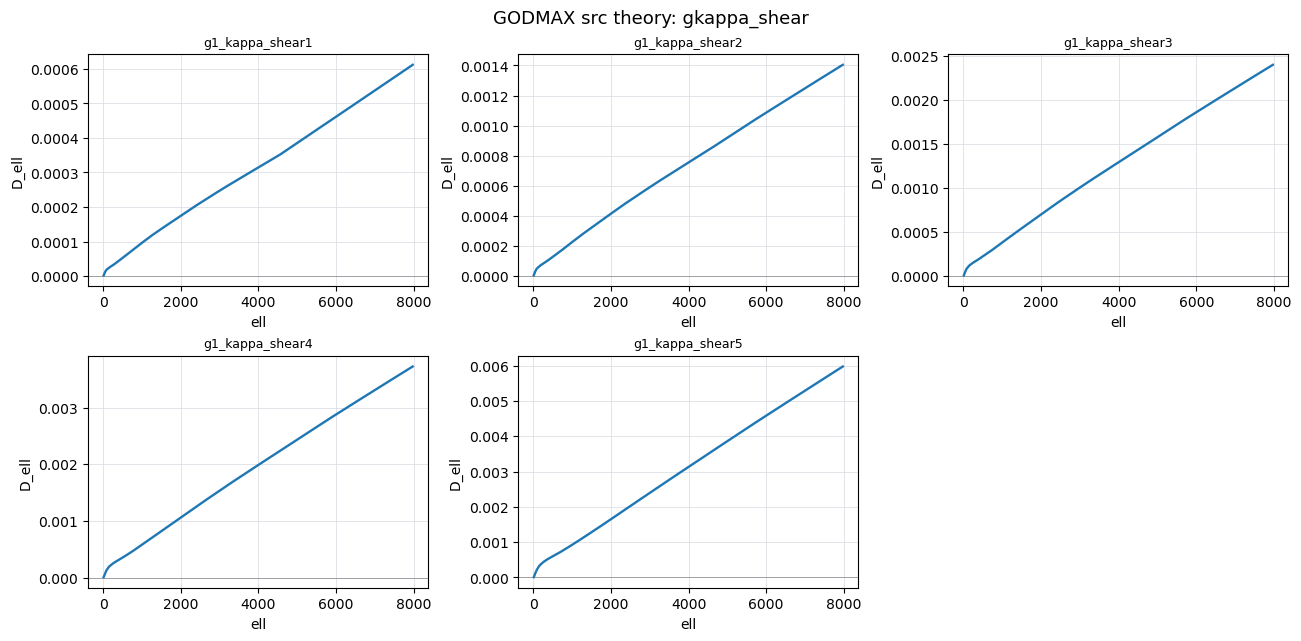

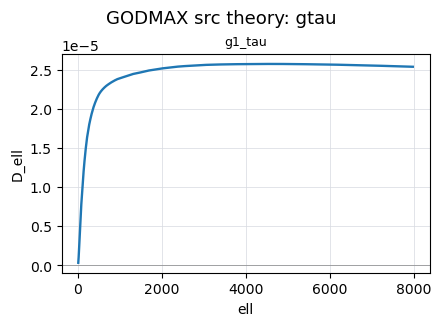

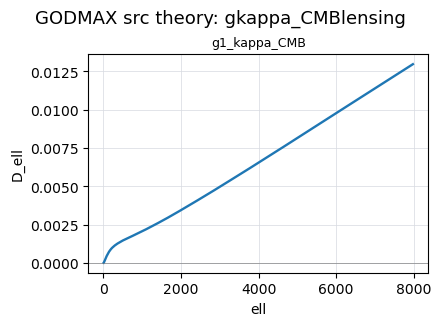

/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_gg.png
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_gy.png
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_ykappa_shear.png
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_gkappa_shear.png
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_gtau.png
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test/plots/multiprobe_theory_predictions_all_probes/src_only_cls_gkappa_CMBlensing.png


In [11]:
def dell_factor(ell_values):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    return ell_values * (ell_values + 1.0) / (2.0 * math.pi)


PLOT_STYLE = {
    "gg": {"use_dell": False, "ylabel": "C_ell", "yscale_if_positive": "log"},
    "gy": {"use_dell": True, "ylabel": "D_ell"},
    "ykappa_shear": {"use_dell": True, "ylabel": "D_ell"},
    "gkappa_shear": {"use_dell": True, "ylabel": "D_ell"},
    "gtau": {"use_dell": True, "ylabel": "D_ell"},
    "gkappa_CMBlensing": {"use_dell": True, "ylabel": "D_ell"},
}


def panel_grid(n_panel):
    ncol = min(4, max(1, int(math.ceil(math.sqrt(n_panel)))))
    nrow = int(math.ceil(n_panel / ncol))
    return nrow, ncol


def plot_group(group, spectra):
    style = PLOT_STYLE[group]
    names = list(spectra.keys())
    nrow, ncol = panel_grid(len(names))
    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(4.3 * ncol, 3.15 * nrow),
        squeeze=False,
        constrained_layout=True,
    )
    for ax, name in zip(axes.flat, names):
        cl = np.asarray(spectra[name], dtype=np.float64)
        y = dell_factor(ell) * cl if style["use_dell"] else cl
        ax.plot(ell, y, lw=1.7)
        ax.axhline(0.0, color="0.45", lw=0.7, alpha=0.6)
        ax.set_xlabel("ell")
        ax.set_ylabel(style["ylabel"])
        ax.set_title(name, fontsize=9)
        ax.grid(True, color="#d8dbe2", lw=0.7, alpha=0.75)
        if style.get("yscale_if_positive") == "log" and np.all(y > 0.0):
            ax.set_yscale("log")
    for ax in axes.flat[len(names):]:
        ax.set_visible(False)
    fig.suptitle(f"GODMAX src theory: {group}", fontsize=13)
    out = OUTPUT_DIR / f"src_only_cls_{group}.png"
    fig.savefig(out, dpi=180)
    plt.show()
    return out


plot_paths = [plot_group(group, spectra) for group, spectra in cls_groups.items()]
for path in plot_paths:
    print(path)